# DefectVision — Notebook 06: CPU-Efficient Multi-Scale Residual U-Net

This is the CPU-compatible version of Model 06. It preserves the experiment's important ideas—residual blocks, multi-scale context, high-resolution skip connections, weighted BCE, Dice loss, boundary-aware loss, validation checkpointing—while reducing channel widths so local CPU training is practical.

**Official baseline:** Test Dice = 0.2070, Test IoU = 0.1434.


In [1]:

from pathlib import Path
import random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "MVTecAD-SEG"
IMG_ROOT = DATA_ROOT / "imgs"
ANN_ROOT = DATA_ROOT / "annotations"

MODEL_DIR = PROJECT_ROOT / "models" / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results" / "model06_cpu"
FIGURES_DIR = RESULTS_DIR / "figures"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cpu")
IMAGE_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 8
LR = 3e-4

class DefectDataset(Dataset):
    def __init__(self, split, augment=False):
        self.augment = augment
        self.img_dir = IMG_ROOT / split
        self.mask_dir = ANN_ROOT / split
        self.image_paths = sorted(self.img_dir.glob("*.png"))
        if not self.image_paths:
            raise RuntimeError(f"No images found: {self.img_dir}")
        missing = [p.name for p in self.image_paths
                   if not (self.mask_dir / p.name).exists()]
        if missing:
            raise RuntimeError(f"Missing masks: {missing[:10]}")
        self.mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
        self.std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        p = self.image_paths[idx]
        image = Image.open(p).convert("RGB").resize(
            (IMAGE_SIZE,IMAGE_SIZE), Image.Resampling.BILINEAR)
        mask = Image.open(self.mask_dir / p.name).convert("L").resize(
            (IMAGE_SIZE,IMAGE_SIZE), Image.Resampling.NEAREST)

        image = torch.from_numpy(
            np.asarray(image,dtype=np.float32)/255.0
        ).permute(2,0,1).contiguous()

        mask = torch.from_numpy(
            (np.asarray(mask,dtype=np.uint8)>0).astype(np.float32)
        ).unsqueeze(0)

        if self.augment:
            if random.random() < 0.5:
                image = torch.flip(image,[2]); mask = torch.flip(mask,[2])
            if random.random() < 0.5:
                image = torch.flip(image,[1]); mask = torch.flip(mask,[1])

        image = (image-self.mean)/self.std
        return image, mask, p.stem

train_dataset = DefectDataset("train", True)
val_dataset = DefectDataset("val", False)
test_dataset = DefectDataset("test", False)

train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=0)
val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=0)
test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=0)

print("PyTorch:",torch.__version__)
print("Device:",DEVICE)
print("Train:",len(train_dataset),"Validation:",len(val_dataset),"Test:",len(test_dataset))
print("Train batches:",len(train_loader))


PyTorch: 2.13.0+cpu
Device: cpu
Train: 880 Validation: 125 Test: 253
Train batches: 220


In [2]:

class ResidualBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        g = min(8,cout)
        self.c1 = nn.Conv2d(cin,cout,3,padding=1,bias=False)
        self.n1 = nn.GroupNorm(g,cout)
        self.c2 = nn.Conv2d(cout,cout,3,padding=1,bias=False)
        self.n2 = nn.GroupNorm(g,cout)
        self.skip = nn.Conv2d(cin,cout,1,bias=False) if cin != cout else nn.Identity()
        self.act = nn.ReLU(inplace=True)

    def forward(self,x):
        identity = self.skip(x)
        x = self.act(self.n1(self.c1(x)))
        x = self.n2(self.c2(x))
        return self.act(x+identity)

class MultiScaleBottleneck(nn.Module):
    def __init__(self,c=64):
        super().__init__()
        b=c//4
        def branch(k,d):
            return nn.Sequential(
                nn.Conv2d(c,b,k,padding=d if k==3 else 0,dilation=d,bias=False),
                nn.GroupNorm(4,b),
                nn.ReLU(inplace=True)
            )
        self.b1=branch(1,1)
        self.b2=branch(3,1)
        self.b3=branch(3,2)
        self.b4=branch(3,4)
        self.fuse=nn.Sequential(
            nn.Conv2d(c,c,1,bias=False),
            nn.GroupNorm(8,c),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        y=torch.cat([self.b1(x),self.b2(x),self.b3(x),self.b4(x)],1)
        return self.fuse(y)+x

class CPU_MSResidualUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1=ResidualBlock(3,16); self.d1=nn.Conv2d(16,16,3,2,1)
        self.e2=ResidualBlock(16,32); self.d2=nn.Conv2d(32,32,3,2,1)
        self.e3=ResidualBlock(32,48); self.d3=nn.Conv2d(48,48,3,2,1)
        self.e4=ResidualBlock(48,64); self.d4=nn.Conv2d(64,64,3,2,1)
        self.b=MultiScaleBottleneck(64)
        self.x4=ResidualBlock(128,48)
        self.x3=ResidualBlock(96,32)
        self.x2=ResidualBlock(64,16)
        self.x1=ResidualBlock(32,16)
        self.ref=ResidualBlock(16,8)
        self.out=nn.Conv2d(8,1,1)

    def up(self,x,t):
        return F.interpolate(x,size=t.shape[-2:],mode="bilinear",align_corners=False)

    def forward(self,x):
        e1=self.e1(x)
        e2=self.e2(self.d1(e1))
        e3=self.e3(self.d2(e2))
        e4=self.e4(self.d3(e3))
        x=self.b(self.d4(e4))
        x=self.x4(torch.cat([self.up(x,e4),e4],1))
        x=self.x3(torch.cat([self.up(x,e3),e3],1))
        x=self.x2(torch.cat([self.up(x,e2),e2],1))
        x=self.x1(torch.cat([self.up(x,e1),e1],1))
        return self.out(self.ref(x))

model=CPU_MSResidualUNet().to(DEVICE)
params=sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:",f"{params:,}")

images,masks,_=next(iter(train_loader))
with torch.no_grad(): outputs=model(images)
print("Input :",tuple(images.shape))
print("Target:",tuple(masks.shape))
print("Output:",tuple(outputs.shape))
assert outputs.shape==masks.shape
print("Forward pass: OK")

# Estimate class imbalance
pos=0; total=0
for _,m,_ in train_loader:
    pos += m.sum().item(); total += m.numel()
pos_weight_value=min((total-pos)/max(pos,1),20.0)
print("Training defect fraction:",pos/total)
print("Positive class weight:",pos_weight_value)

class DiceLoss(nn.Module):
    def forward(self,logits,target):
        p=torch.sigmoid(logits).flatten(1); t=target.flatten(1)
        inter=(p*t).sum(1)
        d=(2*inter+1)/(p.sum(1)+t.sum(1)+1)
        return 1-d.mean()

class BoundaryLoss(nn.Module):
    def boundary(self,x):
        dil=F.max_pool2d(x,3,1,1)
        ero=-F.max_pool2d(-x,3,1,1)
        return (dil-ero).clamp(0,1)
    def forward(self,logits,target):
        return F.l1_loss(self.boundary(torch.sigmoid(logits)),self.boundary(target))

bce=nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value]))
dice=DiceLoss()
boundary=BoundaryLoss()

def loss_fn(logits,target):
    return 0.40*bce(logits,target)+0.45*dice(logits,target)+0.15*boundary(logits,target)

@torch.no_grad()
def metrics(logits,masks,threshold=0.5,eps=1e-7):
    p=(torch.sigmoid(logits)>=threshold).float().flatten(1); t=masks.flatten(1)
    inter=(p*t).sum(1); pa=p.sum(1); ta=t.sum(1); union=pa+ta-inter
    d=(2*inter+eps)/(pa+ta+eps); i=(inter+eps)/(union+eps)
    fp=((p==1)&(t==0)).sum(1).float()
    fn=((p==0)&(t==1)).sum(1).float()
    pr=(inter+eps)/(inter+fp+eps); re=(inter+eps)/(inter+fn+eps)
    return d.mean().item(),i.mean().item(),pr.mean().item(),re.mean().item()


Trainable parameters: 368,169
Input : (4, 3, 256, 256)
Target: (4, 1, 256, 256)
Output: (4, 1, 256, 256)
Forward pass: OK
Training defect fraction: 0.042821103876287285
Positive class weight: 20.0


## 3. Train Model 06

This cell prints progress every 25 batches, so it will not appear frozen. The test set remains untouched until the final evaluation.


In [3]:

optimizer=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=1e-4)
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,mode="max",factor=0.5,patience=2,min_lr=1e-6)

history=[]
best_dice=-1.0
best_epoch=-1
checkpoint_path=MODEL_DIR/"model06_cpu_msresunet_best.pth"
start=time.time()

for epoch in range(1,EPOCHS+1):
    ep_start=time.time()
    model.train()
    running=0.0

    print("\n"+"="*65)
    print(f"START EPOCH {epoch}/{EPOCHS}")

    for i,(images,masks,_) in enumerate(train_loader,1):
        optimizer.zero_grad(set_to_none=True)
        logits=model(images)
        loss=loss_fn(logits,masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step()
        running += loss.item()*images.size(0)

        if i==1 or i%25==0 or i==len(train_loader):
            print(f"  batch {i}/{len(train_loader)} | loss {loss.item():.4f}",flush=True)

    train_loss=running/len(train_loader.dataset)

    model.eval()
    vr=0.0
    rows=[]
    with torch.no_grad():
        for images,masks,_ in val_loader:
            logits=model(images)
            l=loss_fn(logits,masks)
            vr += l.item()*images.size(0)
            rows.append(metrics(logits,masks))

    a=np.asarray(rows)
    val_loss=vr/len(val_loader.dataset)
    vd,vi,vp,vrcl=a[:,0].mean(),a[:,1].mean(),a[:,2].mean(),a[:,3].mean()
    scheduler.step(vd)

    seconds=time.time()-ep_start
    history.append({
        "epoch":epoch,"train_loss":train_loss,"val_loss":val_loss,
        "val_dice":vd,"val_iou":vi,"val_precision":vp,"val_recall":vrcl,
        "lr":optimizer.param_groups[0]["lr"],"seconds":seconds
    })

    print(f"EPOCH {epoch} COMPLETE | train {train_loss:.4f} | val {val_loss:.4f} | "
          f"Dice {vd:.4f} | IoU {vi:.4f} | Precision {vp:.4f} | Recall {vrcl:.4f} | "
          f"{seconds/60:.2f} min",flush=True)

    if vd>best_dice:
        best_dice=vd; best_epoch=epoch
        torch.save({
            "epoch":epoch,
            "model_state_dict":model.state_dict(),
            "optimizer_state_dict":optimizer.state_dict(),
            "val_dice":vd,"val_iou":vi,
            "val_precision":vp,"val_recall":vrcl
        },checkpoint_path)
        print(">>> Best checkpoint saved.",flush=True)

history_df=pd.DataFrame(history)
history_df.to_csv(RESULTS_DIR/"training_history.csv",index=False)

print("\nTRAINING COMPLETE")
print("Best validation Dice:",best_dice)
print("Best epoch:",best_epoch)
print("Total time (min):",round((time.time()-start)/60,2))



START EPOCH 1/8
  batch 1/220 | loss 0.8651
  batch 25/220 | loss 0.7866
  batch 50/220 | loss 1.3980
  batch 75/220 | loss 0.7562
  batch 100/220 | loss 0.6886
  batch 125/220 | loss 0.6896
  batch 150/220 | loss 0.7146
  batch 175/220 | loss 0.6662
  batch 200/220 | loss 0.7220
  batch 220/220 | loss 1.1405
EPOCH 1 COMPLETE | train 0.8296 | val 0.7678 | Dice 0.2423 | IoU 0.1721 | Precision 0.2047 | Recall 0.7546 | 3.94 min
>>> Best checkpoint saved.

START EPOCH 2/8
  batch 1/220 | loss 0.5589
  batch 25/220 | loss 0.7079
  batch 50/220 | loss 0.6816
  batch 75/220 | loss 0.6684
  batch 100/220 | loss 0.5514
  batch 125/220 | loss 0.5897
  batch 150/220 | loss 0.4729
  batch 175/220 | loss 0.6797
  batch 200/220 | loss 0.9484
  batch 220/220 | loss 0.6163
EPOCH 2 COMPLETE | train 0.7755 | val 0.7100 | Dice 0.2348 | IoU 0.1626 | Precision 0.1739 | Recall 0.8784 | 3.98 min

START EPOCH 3/8
  batch 1/220 | loss 0.5591
  batch 25/220 | loss 0.6042
  batch 50/220 | loss 3.0863
  batch 75

## 4. Evaluate the best checkpoint on the held-out test set


BEST CHECKPOINT
Best epoch: 8
Best validation Dice: 0.41668327304068953
Best validation IoU: 0.30983998521696776
Checkpoint loaded successfully.

MODEL 06 TEST RESULTS
test_loss: 0.674166
test_dice: 0.353307
test_iou: 0.252814
test_precision: 0.323523
test_recall: 0.682221

BASELINE vs MODEL 06


,model,Dice,IoU,Precision,Recall
0,Notebook 04 baseline,0.206994,0.143440,0.313602,0.539982
1,Notebook 06 CPU MS-Residual U-Net,0.353307,0.252814,0.323523,0.682221


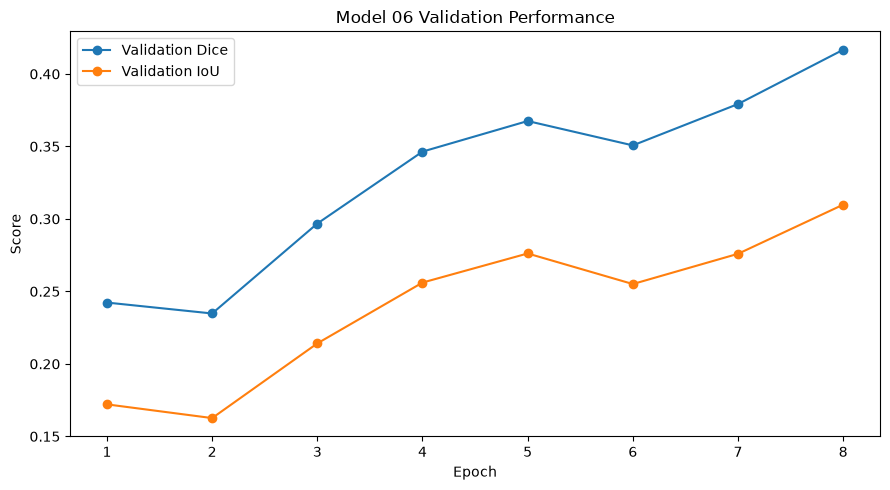

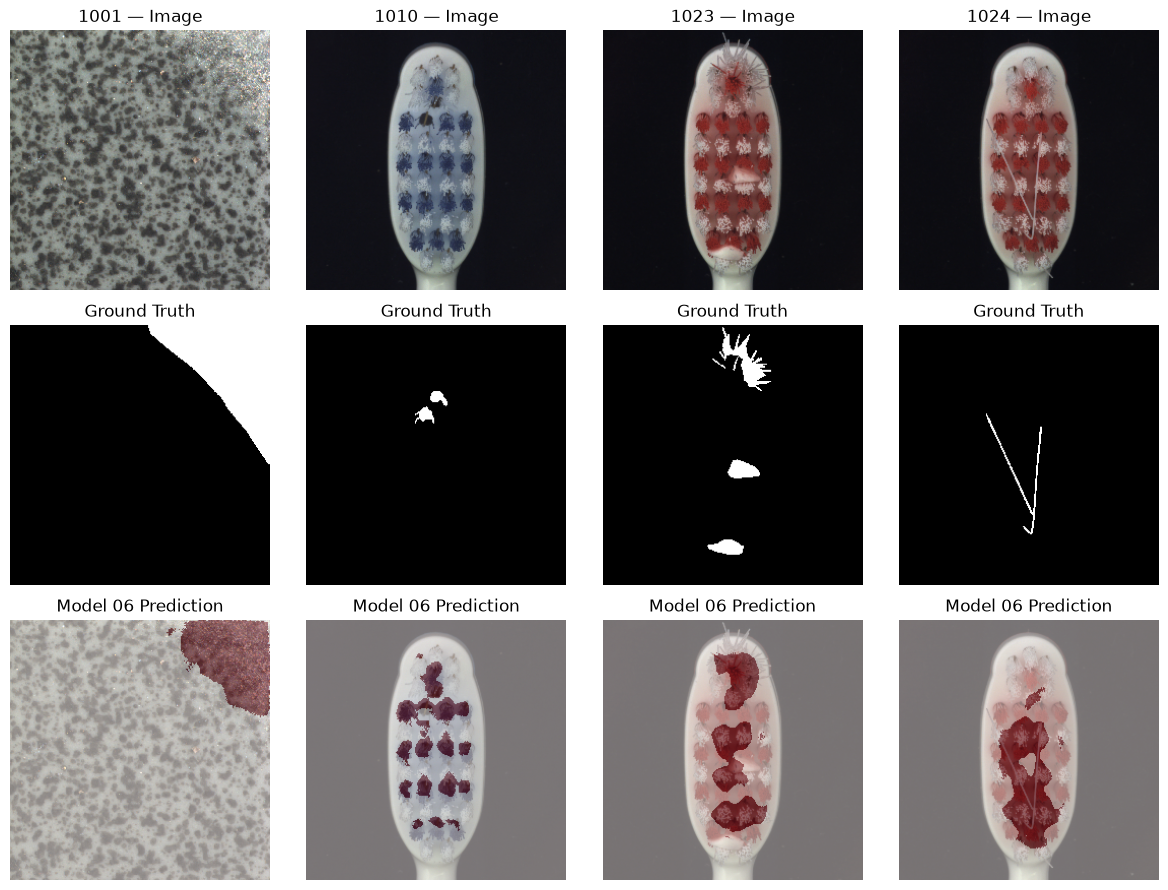


CELL 4 COMPLETE


In [8]:
# ============================================================
# CELL 4 — LOAD BEST CHECKPOINT + TEST EVALUATION + VISUALS
# ============================================================

# ------------------------------------------------------------
# 1. Load the best validation checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("=" * 60)
print("BEST CHECKPOINT")
print("=" * 60)

print("Best epoch:", checkpoint["epoch"])
print("Best validation Dice:", checkpoint["val_dice"])
print("Best validation IoU:", checkpoint["val_iou"])
print("Checkpoint loaded successfully.")


# ------------------------------------------------------------
# 2. Evaluate on the untouched test set
# ------------------------------------------------------------

test_rows = []
total_test_loss = 0.0
total_test_images = 0

with torch.no_grad():

    for images, masks, ids in test_loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        logits = model(images)

        loss = loss_fn(
            logits,
            masks
        )

        batch_size = images.size(0)

        total_test_loss += (
            loss.item() * batch_size
        )

        total_test_images += batch_size

        test_rows.append(
            metrics(
                logits,
                masks,
                threshold=0.5
            )
        )


test_rows = np.asarray(test_rows)

test_results = {
    "test_loss":
        total_test_loss / total_test_images,

    "test_dice":
        test_rows[:, 0].mean(),

    "test_iou":
        test_rows[:, 1].mean(),

    "test_precision":
        test_rows[:, 2].mean(),

    "test_recall":
        test_rows[:, 3].mean()
}


# ------------------------------------------------------------
# 3. Print Model 06 results
# ------------------------------------------------------------

print()
print("=" * 60)
print("MODEL 06 TEST RESULTS")
print("=" * 60)

for key, value in test_results.items():

    print(
        f"{key}: {value:.6f}"
    )


# ------------------------------------------------------------
# 4. Compare with Notebook 04 baseline
# ------------------------------------------------------------

comparison = pd.DataFrame([
    {
        "model": "Notebook 04 baseline",

        "Dice": 0.206994,

        "IoU": 0.143440,

        "Precision": 0.313602,

        "Recall": 0.539982
    },

    {
        "model":
            "Notebook 06 CPU MS-Residual U-Net",

        "Dice":
            test_results["test_dice"],

        "IoU":
            test_results["test_iou"],

        "Precision":
            test_results["test_precision"],

        "Recall":
            test_results["test_recall"]
    }
])


print()
print("=" * 60)
print("BASELINE vs MODEL 06")
print("=" * 60)

display(comparison)


# Save results
comparison.to_csv(
    RESULTS_DIR / "baseline_vs_model06.csv",
    index=False
)

pd.DataFrame(
    [test_results]
).to_csv(
    RESULTS_DIR / "model06_test_results.csv",
    index=False
)


# ------------------------------------------------------------
# 5. Plot validation performance
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    history_df["epoch"],
    history_df["val_dice"],
    marker="o",
    label="Validation Dice"
)

ax.plot(
    history_df["epoch"],
    history_df["val_iou"],
    marker="o",
    label="Validation IoU"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title(
    "Model 06 Validation Performance"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "validation_metrics.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 6. Visualize predictions
# ------------------------------------------------------------

images, masks, ids = next(
    iter(test_loader)
)

with torch.no_grad():

    logits = model(
        images.to(DEVICE)
    )

    probabilities = torch.sigmoid(
        logits
    ).cpu()


# Undo ImageNet normalization
mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)


n = min(
    6,
    len(images)
)

fig, axes = plt.subplots(
    3,
    n,
    figsize=(3 * n, 9)
)


for i in range(n):

    # Original image
    image = (
        images[i] * std + mean
    ).clamp(
        0,
        1
    )

    image = (
        image
        .permute(1, 2, 0)
        .numpy()
    )

    # Ground truth
    ground_truth = (
        masks[i, 0]
        .numpy()
    )

    # Binary prediction
    prediction = (
        probabilities[i, 0]
        .numpy()
        >= 0.5
    ).astype(float)


    # Image
    axes[0, i].imshow(
        image
    )

    axes[0, i].set_title(
        f"{ids[i]} — Image"
    )

    axes[0, i].axis("off")


    # Ground truth
    axes[1, i].imshow(
        ground_truth,
        cmap="gray"
    )

    axes[1, i].set_title(
        "Ground Truth"
    )

    axes[1, i].axis("off")


    # Prediction overlay
    axes[2, i].imshow(
        image
    )

    axes[2, i].imshow(
        prediction,
        cmap="Reds",
        alpha=0.45
    )

    axes[2, i].set_title(
        "Model 06 Prediction"
    )

    axes[2, i].axis("off")


plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "model06_predictions.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()


print()
print("=" * 60)
print("CELL 4 COMPLETE")
print("=" * 60)

## 5. Decision rule

The official baseline is Dice 0.2070 / IoU 0.1434. Do not tune the architecture using the test score. Model 06 succeeds only if its held-out test performance provides a meaningful improvement over that benchmark.
